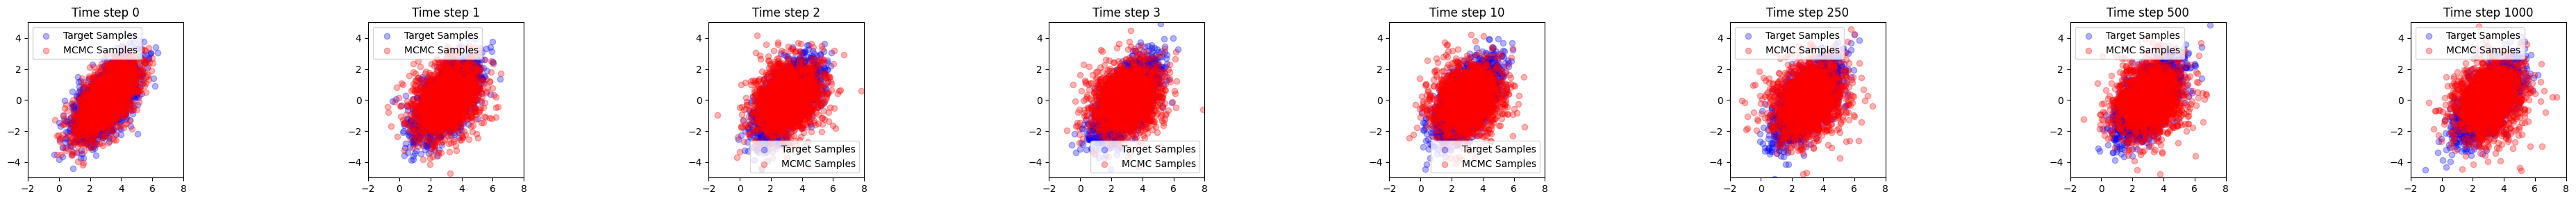

In [23]:
# MCMC via random 1D-projection resampling for a 2D Gaussian
# - Runs the chain for T steps from N initial points (N x 2)
# - At each step, picks a random direction v (uniform on the unit circle),
#   resamples the projected coordinate t ~ N(v^T mu, v^T Sigma v),
#   and replaces x <- x + v (t - v^T x).
#
# The script also visualizes the final samples versus the target Gaussian
# using a contour plot of the target density and a scatter of the final chain state.

import numpy as np
import matplotlib.pyplot as plt

mu = np.array([3., 0.0])  # target mean
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.6]])  # target covariance (must be SPD)
# ----------------------------
# Core MCMC functions
# ----------------------------

def random_unit_directions(num, rng: np.random.Generator, dim=2):
    """Sample 'num' unit vectors uniformly on the 2D unit circle."""
    gaussian = rng.standard_normal(size=(num, dim))
    normalized = gaussian / np.linalg.norm(gaussian, axis=1, keepdims=True)
    return normalized

def sample_from_projection(v, rng: np.random.Generator):
    """Sample from the 1D Gaussian defined by the projection parameters."""
    global mu, Sigma
    m = np.einsum('ij, j -> i', v, mu)  # (num,)
    s2 = np.einsum('ij, jk, ik -> i', v, Sigma, v)  # (num,)
    s = np.sqrt(np.maximum(s2, 0.0))
    return m + s * rng.standard_normal(size=m.shape)

def mcmc_step(x, rng, dim=2):
    """One step for a batch of points x: shape (N, 2)."""
    N = x.shape[0]
    v = random_unit_directions(N, rng, dim=dim)                  # (N,dim)
    t = sample_from_projection(v, rng)                     # (N,)
    dots = np.einsum('ij, ij -> i', v, x)                 # (N,)
    x_next = x + v * (t - dots)[:, None]                  # replace projected coord
    return x_next

def run_chain(init_points, T, seed=0):
    """Run T steps of the chain from init_points (N,2).
    Returns an array of shape (T+1, N, 2).
    """
    rng = np.random.default_rng(seed)
    N = init_points.shape[0]
    samples = np.empty((T+1, N, 2), dtype=float)
    samples[0] = init_points
    x = init_points.copy()
    for t in range(1, T+1):
        x = mcmc_step(x, rng)
        samples[t] = x
    return samples

# You can change these parameters:
T = 1000                    # number of steps
N = 2000                     # number of particles

# Initialize starting points (e.g., all at a corner or a wide Gaussian)
rng_demo = np.random.default_rng(42)

init_points = rng_demo.multivariate_normal(mu, Sigma, size=N)
# init_points = rng_demo.uniform(-5, 5, size=(N, 2))
# Run the chain
samples = run_chain(init_points, T, seed=123)

snapshots = [0, 1, 2, 3, 10, T//4, T//2, T]  # time steps to visualize
fig, axs = plt.subplots(1, len(snapshots), figsize=(5 * len(snapshots), 3))
for ax, time in zip(axs, snapshots):
    # Visualize final samples vs target
    real_samples = rng_demo.multivariate_normal(mu, Sigma, size=N)
    # plot the scatterplots for both
    ax.scatter(real_samples[:, 0], real_samples[:, 1], color='blue', alpha=0.3, label='Target Samples')
    ax.scatter(samples[time, :, 0], samples[time, :, 1], color='red',
                alpha=0.3, label='MCMC Samples')
    ax.set_title(f'Time step {time}')
    xlim0 = mu[0] - 5
    xlim1 = mu[0] + 5
    ylim0 = mu[1] - 5
    ylim1 = mu[1] + 5
    ax.set_xlim(xlim0, xlim1)
    ax.set_ylim(ylim0, ylim1)
    ax.set_aspect('equal')
    ax.legend()
plt.tight_layout()